In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.lif_model import run_LIF_network, visualize_spikes

#### keep motor neurons in the circuit

In [3]:
keep_spiking_only = True

weights = pd.read_csv("../data/manc t1 connectome data/W_20250813_DNtoMN_unsorted.csv").drop(columns=["bodyId_pre"]).values
table = pd.read_csv("../data/manc t1 connectome data/wTable_20250813_DNtoMN_unsorted_withModules.csv")
minicircuit_size = (table["class"] != "motor neuron").sum()

if keep_spiking_only:
    keep_bodyIDs = [10093, 10707, 11751, 13905, 12686]
    keep = table["bodyId"].apply(lambda x: x in keep_bodyIDs)
else:
    send_connections = (weights[np.arange(minicircuit_size)] != 0).any(0)
    receive_connections = (weights[:, np.arange(minicircuit_size)] != 0).any(1)
    keep = send_connections | receive_connections

weights = weights[keep][:, keep]
table = table[keep]
weights[table["class"] == "motor neuron"] = 0

network_size = keep.sum()
network_input = np.zeros(keep.sum())
network_input[table["class"] == "descending neuron"] = 1
network_weights = weights.T

In [4]:
def default_params() -> dict:
    params = {}

    params["V_rest"] = -52e-3  # [V]
    params["V_reset"] = -52e-3  # [V]
    params["V_thresh"] = -45e-3  # [V]
    params["t_refractory"] = 2.2e-3  # [s]
    params["tau_membrane"] = 20e-3  # [s]
    params["tau_synaptic"] = 5e-3  # [s]
    params["w_synaptic"] = 0.275e-3  # [V]
    params["t_delay"] = 1.8e-3  # [s]
    params["membrane_conductance"] = 10e-9  # [S]
    params["V_init"] = -52e-3  # [V]
    params["dt"] = 1e-5  # [s]
    params["simulation_time"] = 0.5  # [s]
    params["network_input"] = 0.15e-9  # [A]
    params["network_size"] = network_size
    params["network_weights"] = network_weights
    return params


params = default_params()

In [5]:
history_V, history_spikes = run_LIF_network(params, network_input)

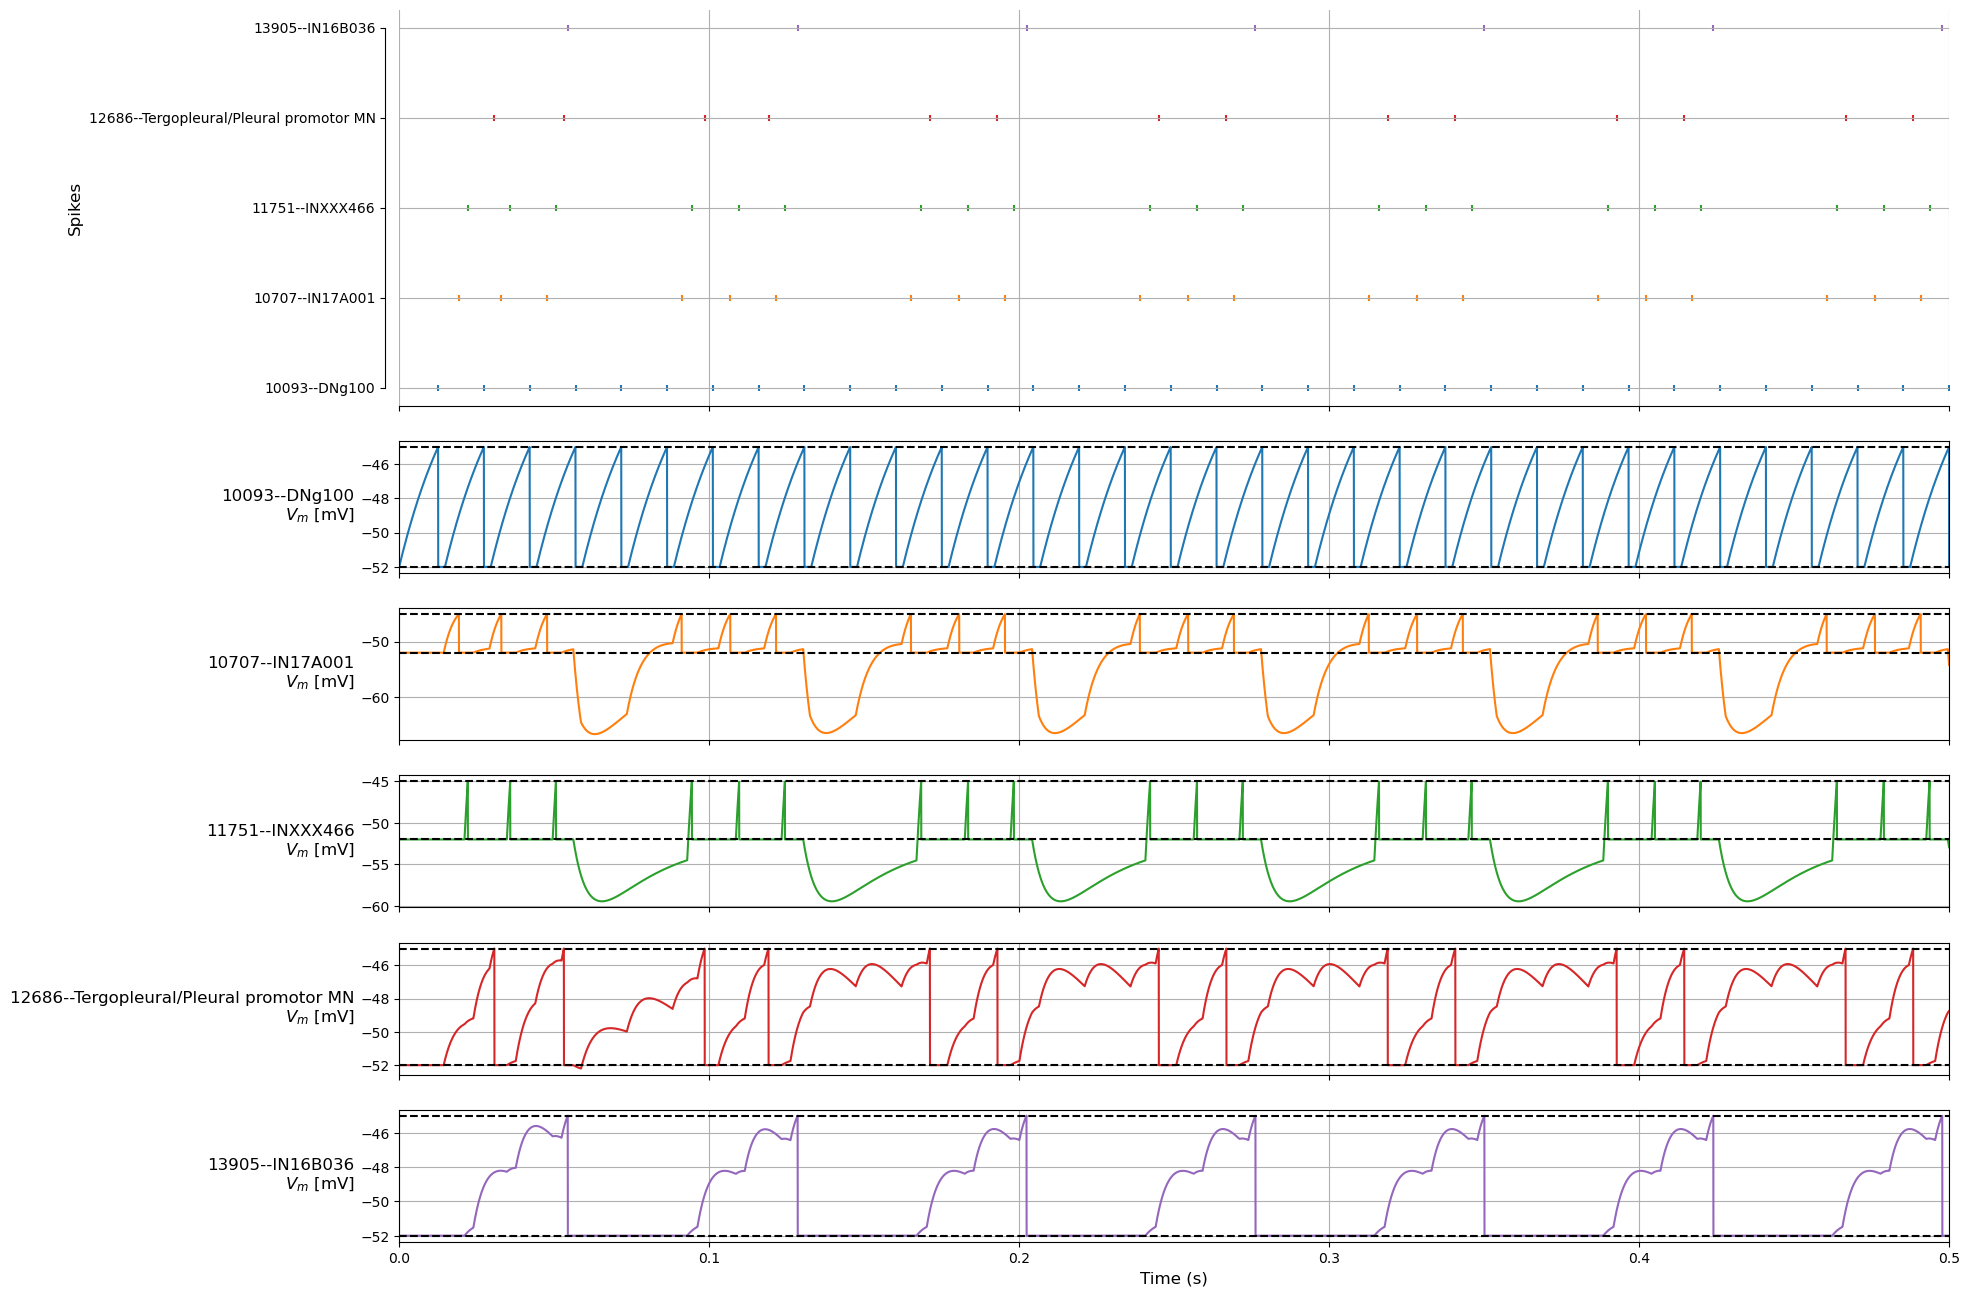

In [6]:
fig, ax = visualize_spikes(
    spike_activity=history_spikes,
    membrane_potential=history_V,
    duration=params["simulation_time"],
    dt=params["dt"],
    neuron_labels=list(table[["bodyId", "type"]].apply(lambda x: f"{x['bodyId']}--{x['type']}", axis=1)),
    spike_marker_size=20,
    spike_figure_height=6,
    y_label_rotation=0,
    show_plot=False,
)  # type: ignore
plt.show()

In [7]:
params["simulation_time"] = 5
network_inputs = np.arange(0.07, 0.4, 0.005) * 1e-9
frequencies_mean = {}
frequencies_std = {}
for net_in in network_inputs:
    frequencies_mean[net_in] = []
    frequencies_std[net_in] = []
    params["network_input"] = net_in
    print(f"Running simulation with network input: {net_in:.2e}")
    history_V, history_spikes = run_LIF_network(params, network_input)
    for i in range(params["network_size"]):
        spike_time_ids = np.where(history_spikes[:, i])[0]
        spike_intervals = np.diff(spike_time_ids)
        if len(spike_intervals) == 0:
            frequencies_mean[net_in].append(0)
            frequencies_std[net_in].append(0)
            continue
        middle_interval = (spike_intervals.max() + spike_intervals.min() / 2) / 2
        burst_start_ids = np.hstack(
            [[spike_time_ids[0]], spike_time_ids[np.where(spike_intervals >= middle_interval)[0] + 1]]
        )
        oscillation_frequency = 1 / (np.diff(burst_start_ids) * params["dt"])
        frequencies_mean[net_in].append(oscillation_frequency.mean())
        frequencies_std[net_in].append(oscillation_frequency.std())

Running simulation with network input: 7.00e-11
Running simulation with network input: 7.50e-11
Running simulation with network input: 8.00e-11
Running simulation with network input: 8.50e-11
Running simulation with network input: 9.00e-11
Running simulation with network input: 9.50e-11
Running simulation with network input: 1.00e-10
Running simulation with network input: 1.05e-10
Running simulation with network input: 1.10e-10
Running simulation with network input: 1.15e-10
Running simulation with network input: 1.20e-10
Running simulation with network input: 1.25e-10
Running simulation with network input: 1.30e-10
Running simulation with network input: 1.35e-10
Running simulation with network input: 1.40e-10
Running simulation with network input: 1.45e-10
Running simulation with network input: 1.50e-10
Running simulation with network input: 1.55e-10
Running simulation with network input: 1.60e-10
Running simulation with network input: 1.65e-10
Running simulation with network input: 1

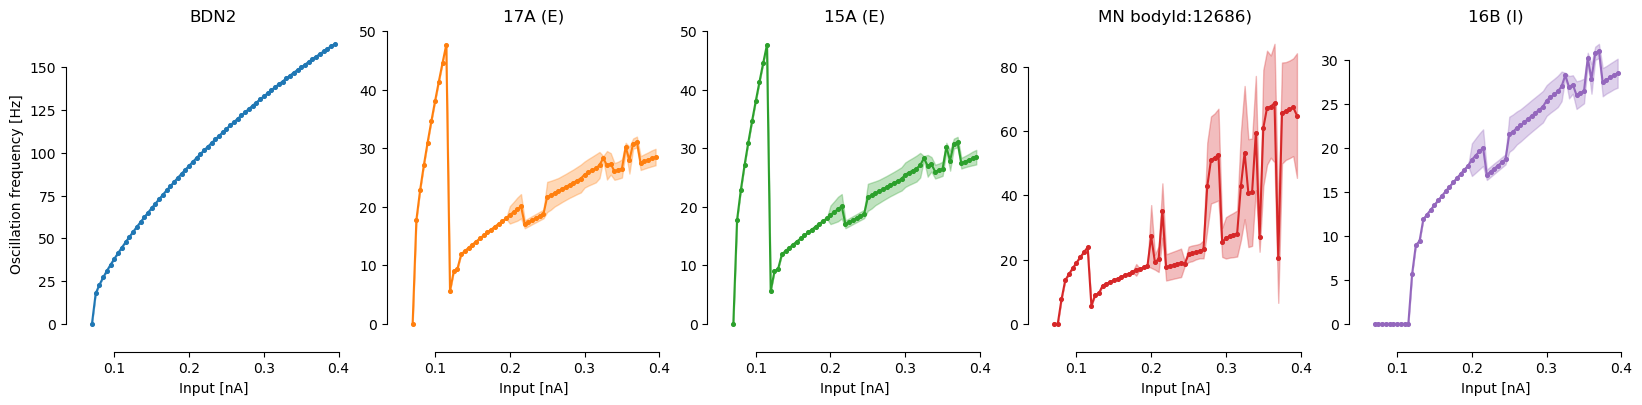

In [ ]:
means = np.array([v for v in frequencies_mean.values()])
stds = np.array([v for v in frequencies_std.values()])
net_ins = np.array(list(frequencies_mean.keys())) * 1e9
neuron_labels = ["BDN2", "17A (E)", "15A (E)", "MN bodyId:12686", "16B (I)"]
fig, axes = plt.subplots(1, params["network_size"], figsize=(4 * params["network_size"], 4), sharex=True)
for i in range(params["network_size"]):
    axes[i].plot(net_ins, means[:, i], c=f"C{i}") # type: ignore
    axes[i].scatter(net_ins, means[:, i], color=f"C{i}", s=7) # type: ignore
    axes[i].fill_between(net_ins, means[:, i] - stds[:, i], means[:, i] + stds[:, i], alpha=0.3, color=f"C{i}") # type: ignore
    axes[i].set_xlabel("Input [nA]") # type: ignore
    axes[i].set_title(neuron_labels[i]) # type: ignore
    sns.despine(offset=10, trim=True, ax=axes[i]) # type: ignore
axes[0].set_ylabel("Oscillation frequency [Hz]") # type: ignore
plt.show()